# Notebook 07 — Ensemble Evaluation & Final Comparison (v2)
Combines Model A (TF-IDF), Model C v1 (buggy), and Model C v2 (fixed + focal loss) predictions via weighted average. Compares all individual models and three ensemble configurations.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import pickle, json
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from src.config import DATA_DIR, MODEL_A_DIR, MODEL_B_DIR, MODEL_C_DIR, ENSEMBLE_DIR
from src.data import load_label_binarizer
from src.evaluate import full_metrics, tune_global_threshold, head_tail_analysis
from src.models import EnsemblePredictor

MODEL_C_V2_DIR = MODEL_C_DIR / 'v2'

mlb   = load_label_binarizer()
vocab = list(mlb.classes_)

print(f'Labels: {len(vocab)}')

Labels: 50


## 1. Load All Model Probabilities

In [3]:
import scipy.sparse as sp

# Ground truth
Y_test  = np.load(DATA_DIR / 'Y_test.npy')
Y_train = np.load(DATA_DIR / 'Y_train.npy')
Y_val   = np.load(DATA_DIR / 'Y_val.npy')

# Model A: recompute probabilities using the correct vectorizer
X_test_tfidf = sp.load_npz(DATA_DIR / 'X_test_tfidf.npz')
X_val_tfidf  = sp.load_npz(DATA_DIR / 'X_val_tfidf.npz')

with open(MODEL_A_DIR / 'clf_sgd.pkl', 'rb') as f:
    clf_a = pickle.load(f)

# Check if feature dims match; if not, re-vectorize from the saved vectorizer
if X_test_tfidf.shape[1] != clf_a.estimators_[0].n_features_in_:
    print(f'Feature mismatch: TF-IDF has {X_test_tfidf.shape[1]} but model expects {clf_a.estimators_[0].n_features_in_}')
    print('Re-vectorizing with saved vectorizer...')
    with open(DATA_DIR / 'tfidf_vectorizer.pkl', 'rb') as f:
        tfidf_vec = pickle.load(f)
    # Load raw text from parquet
    cohort_test = pd.read_parquet(DATA_DIR / 'cohort_test_clean.parquet')
    cohort_val  = pd.read_parquet(DATA_DIR / 'cohort_val_clean.parquet')
    X_test_tfidf = tfidf_vec.transform(cohort_test['text_clean'])
    X_val_tfidf  = tfidf_vec.transform(cohort_val['text_clean'])
    print(f'Re-vectorized: test={X_test_tfidf.shape}, val={X_val_tfidf.shape}')

P_a_test = clf_a.predict_proba(X_test_tfidf)
P_a_val  = clf_a.predict_proba(X_val_tfidf)
with open(MODEL_A_DIR / 'results.json') as f:
    T_a = json.load(f)['test']['threshold']

# Model B
P_b_test = np.load(MODEL_B_DIR / 'P_test.npy')
with open(MODEL_B_DIR / 'test_results.json') as f:
    T_b = json.load(f)['threshold']

# Model C v1
P_c1_test = np.load(MODEL_C_DIR / 'P_test.npy')
P_c1_val  = np.load(MODEL_C_DIR / 'P_val.npy')
with open(MODEL_C_DIR / 'test_results.json') as f:
    T_c1 = json.load(f)['Threshold']

# Model C v2 (calibrated probabilities)
P_c2_test = np.load(MODEL_C_V2_DIR / 'P_test_calibrated.npy')
P_c2_val_raw = np.load(MODEL_C_V2_DIR / 'P_val_best.npy')
Y_c2_val = np.load(MODEL_C_V2_DIR / 'Y_val_best.npy')
with open(MODEL_C_V2_DIR / 'temperature.json') as f:
    temp_info = json.load(f)
with open(MODEL_C_V2_DIR / 'test_results.json') as f:
    c2_results = json.load(f)
    T_c2 = c2_results['global_threshold']['Threshold']

print(f'Model A probs:    {P_a_test.shape}  threshold: {T_a}')
print(f'Model B probs:    {P_b_test.shape}  threshold: {T_b}')
print(f'Model C v1 probs: {P_c1_test.shape}  threshold: {T_c1}')
print(f'Model C v2 probs: {P_c2_test.shape}  threshold: {T_c2}  (calibrated, temp={temp_info["temperature"]:.4f})')

Model A probs:    (18852, 50)  threshold: 0.5250000000000001
Model B probs:    (18852, 50)  threshold: 0.2750000000000001
Model C v1 probs: (18852, 50)  threshold: 0.625
Model C v2 probs: (18852, 50)  threshold: 0.05  (calibrated, temp=0.0427)


## 2. Tune Ensemble Weights

We try three ensemble combos:
- **Ensemble v1**: Model A + Model C v1 (original)
- **Ensemble v2**: Model A + Model C v2 (improved)
- **Ensemble v3**: Model A + Model C v1 + Model C v2 (triple blend)

In [4]:
# --- Ensemble v1: A + C_v1 (original) ---
best_w1, best_t1, best_f1_1 = 0.5, 0.5, 0.0
for w in np.arange(0.0, 1.05, 0.05):
    P_ens_val = w * P_a_val + (1 - w) * P_c1_val
    t, f1 = tune_global_threshold(P_ens_val, Y_val)
    if f1 > best_f1_1:
        best_f1_1, best_w1, best_t1 = f1, w, t

print(f'Ensemble v1 (A + C_v1): w_A={best_w1:.2f}  threshold={best_t1:.3f}  val_F1={best_f1_1:.4f}')
P_ens1_test = best_w1 * P_a_test + (1 - best_w1) * P_c1_test

# --- Ensemble v2: A + C_v2 (improved) ---
best_w2, best_t2, best_f1_2 = 0.5, 0.5, 0.0
for w in np.arange(0.0, 1.05, 0.05):
    P_ens_val = w * P_a_val + (1 - w) * P_c2_val_raw
    t, f1 = tune_global_threshold(P_ens_val, Y_c2_val)
    if f1 > best_f1_2:
        best_f1_2, best_w2, best_t2 = f1, w, t

print(f'Ensemble v2 (A + C_v2): w_A={best_w2:.2f}  threshold={best_t2:.3f}  val_F1={best_f1_2:.4f}')
P_ens2_test = best_w2 * P_a_test + (1 - best_w2) * P_c2_test

# --- Ensemble v3: A + C_v1 + C_v2 (triple blend) ---
best_wa, best_wc1, best_t3, best_f1_3 = 0.5, 0.25, 0.5, 0.0
for wa in np.arange(0.0, 1.05, 0.1):
    for wc1 in np.arange(0.0, 1.05 - wa, 0.1):
        wc2 = round(1.0 - wa - wc1, 2)
        if wc2 < 0:
            continue
        P_ens_val = wa * P_a_val + wc1 * P_c1_val + wc2 * P_c2_val_raw
        t, f1 = tune_global_threshold(P_ens_val, Y_c2_val)
        if f1 > best_f1_3:
            best_f1_3, best_wa, best_wc1, best_t3 = f1, wa, wc1, t

best_wc2 = round(1.0 - best_wa - best_wc1, 2)
print(f'Ensemble v3 (A + C_v1 + C_v2): w_A={best_wa:.2f}  w_C1={best_wc1:.2f}  w_C2={best_wc2:.2f}  threshold={best_t3:.3f}  val_F1={best_f1_3:.4f}')
P_ens3_test = best_wa * P_a_test + best_wc1 * P_c1_test + best_wc2 * P_c2_test

Ensemble v1 (A + C_v1): w_A=0.65  threshold=0.625  val_F1=0.6294
Ensemble v2 (A + C_v2): w_A=0.35  threshold=0.425  val_F1=0.6668
Ensemble v3 (A + C_v1 + C_v2): w_A=0.30  w_C1=0.00  w_C2=0.70  threshold=0.400  val_F1=0.6658


## 3. Full Comparison Table

In [5]:
rows = [
    full_metrics(P_a_test,    Y_test, T_a,      'Model A (TF-IDF + SGD)'),
    full_metrics(P_b_test,    Y_test, T_b,      'Model B (ClinicalBERT)'),
    full_metrics(P_c1_test,   Y_test, T_c1,     'Model C v1 (Chunk+Attn)'),
    full_metrics(P_c2_test,   Y_test, T_c2,     'Model C v2 (Fixed+Focal)'),
    full_metrics(P_ens1_test, Y_test, best_t1,  f'Ensemble v1 (A+Cv1, w={best_w1:.2f})'),
    full_metrics(P_ens2_test, Y_test, best_t2,  f'Ensemble v2 (A+Cv2, w={best_w2:.2f})'),
    full_metrics(P_ens3_test, Y_test, best_t3,  f'Ensemble v3 (A+Cv1+Cv2)'),
]

comparison_df = pd.DataFrame(rows)
print('\n=== Final Model Comparison (Test Set) ===')
print(comparison_df.to_string(index=False))

comparison_df.to_csv(ENSEMBLE_DIR / 'final_comparison_all_models.csv', index=False)
print('\nSaved to', ENSEMBLE_DIR / 'final_comparison_all_models.csv')


=== Final Model Comparison (Test Set) ===
                      Model  Threshold  Micro-F1  Macro-F1  Micro-Prec  Micro-Rec  Macro-AUPRC  Micro-AUROC
     Model A (TF-IDF + SGD)      0.525    0.5952    0.5696      0.4941     0.7483       0.5741       0.9250
     Model B (ClinicalBERT)      0.275    0.5242    0.4429      0.5247     0.5237       0.4541       0.8686
    Model C v1 (Chunk+Attn)      0.625    0.5305    0.5000      0.4191     0.7225       0.5201       0.8938
   Model C v2 (Fixed+Focal)      0.050    0.5508    0.4309      0.7895     0.4230       0.5567       0.9185
Ensemble v1 (A+Cv1, w=0.65)      0.625    0.6249    0.5923      0.5712     0.6897       0.5921       0.9328
Ensemble v2 (A+Cv2, w=0.35)      0.425    0.5271    0.4005      0.8107     0.3905       0.6094       0.9358
    Ensemble v3 (A+Cv1+Cv2)      0.400    0.5261    0.3992      0.8103     0.3895       0.6094       0.9359

Saved to /home/croha/ICD-CPT-Code-Prediction/data/models/ensemble/final_comparison_all_model

## 4. Head / Torso / Tail Breakdown (All Models)

In [6]:
preds_a    = (P_a_test    >= T_a).astype(int)
preds_b    = (P_b_test    >= T_b).astype(int)
preds_c1   = (P_c1_test   >= T_c1).astype(int)
preds_c2   = (P_c2_test   >= T_c2).astype(int)
preds_ens1 = (P_ens1_test >= best_t1).astype(int)
preds_ens2 = (P_ens2_test >= best_t2).astype(int)
preds_ens3 = (P_ens3_test >= best_t3).astype(int)

f1_a    = f1_score(Y_test, preds_a,    average=None, zero_division=0)
f1_b    = f1_score(Y_test, preds_b,    average=None, zero_division=0)
f1_c1   = f1_score(Y_test, preds_c1,   average=None, zero_division=0)
f1_c2   = f1_score(Y_test, preds_c2,   average=None, zero_division=0)
f1_ens1 = f1_score(Y_test, preds_ens1, average=None, zero_division=0)
f1_ens2 = f1_score(Y_test, preds_ens2, average=None, zero_division=0)
f1_ens3 = f1_score(Y_test, preds_ens3, average=None, zero_division=0)

freq = Y_train.sum(0)
label_df = pd.DataFrame({
    'code': vocab, 'freq': freq,
    'f1_A': f1_a, 'f1_B': f1_b, 'f1_C_v1': f1_c1, 'f1_C_v2': f1_c2,
    'f1_Ens_v1': f1_ens1, 'f1_Ens_v2': f1_ens2, 'f1_Ens_v3': f1_ens3,
})

print(f'{"Bucket":25s}  {"n":>5}  {"A":>7}  {"B":>7}  {"Cv1":>7}  {"Cv2":>7}  {"Ev1":>7}  {"Ev2":>7}  {"Ev3":>7}')
print('-' * 95)
for lo, hi, name in [(500, 1e9, 'head (>=500)'), (100, 499, 'torso (100-499)'), (0, 99, 'tail (<100)')]:
    s = label_df[(label_df.freq >= lo) & (label_df.freq <= hi)]
    if len(s) == 0:
        continue
    print(f'{name:25s}  {len(s):5d}  {s.f1_A.mean():7.4f}  {s.f1_B.mean():7.4f}  '
          f'{s.f1_C_v1.mean():7.4f}  {s.f1_C_v2.mean():7.4f}  '
          f'{s.f1_Ens_v1.mean():7.4f}  {s.f1_Ens_v2.mean():7.4f}  {s.f1_Ens_v3.mean():7.4f}')

Bucket                         n        A        B      Cv1      Cv2      Ev1      Ev2      Ev3
-----------------------------------------------------------------------------------------------
head (>=500)                  50   0.5696   0.4429   0.5000   0.4309   0.5923   0.4005   0.3992


## 5. Visualization — F1 Comparison Across Models

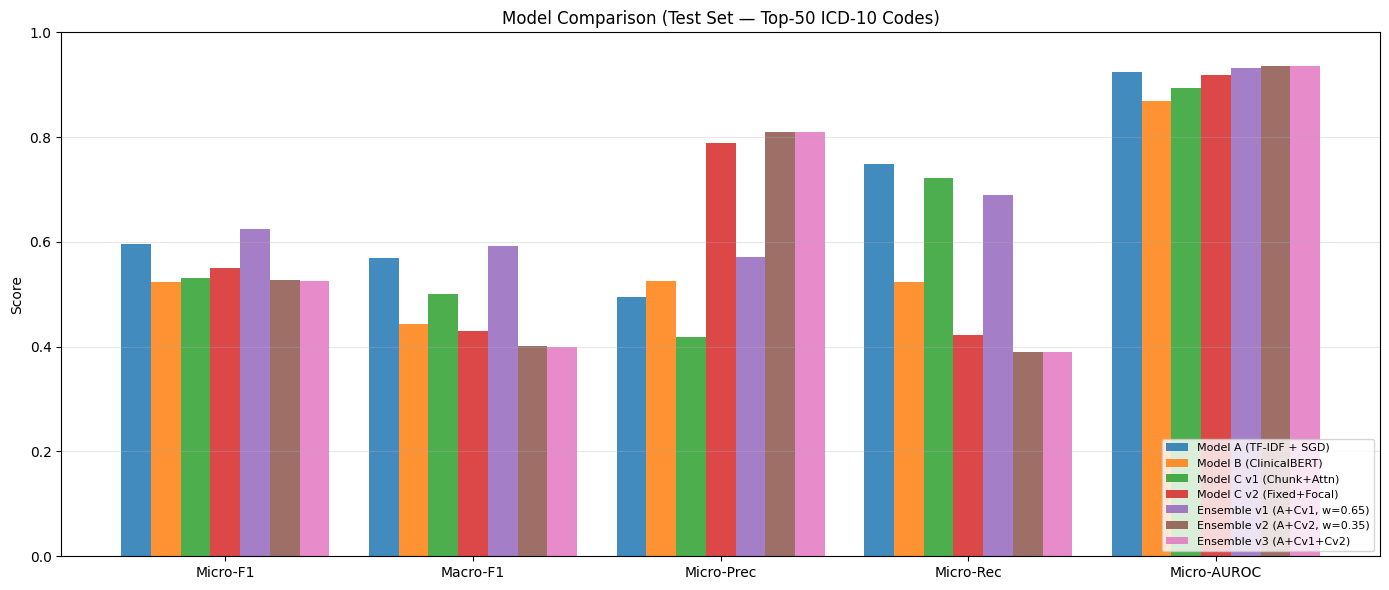

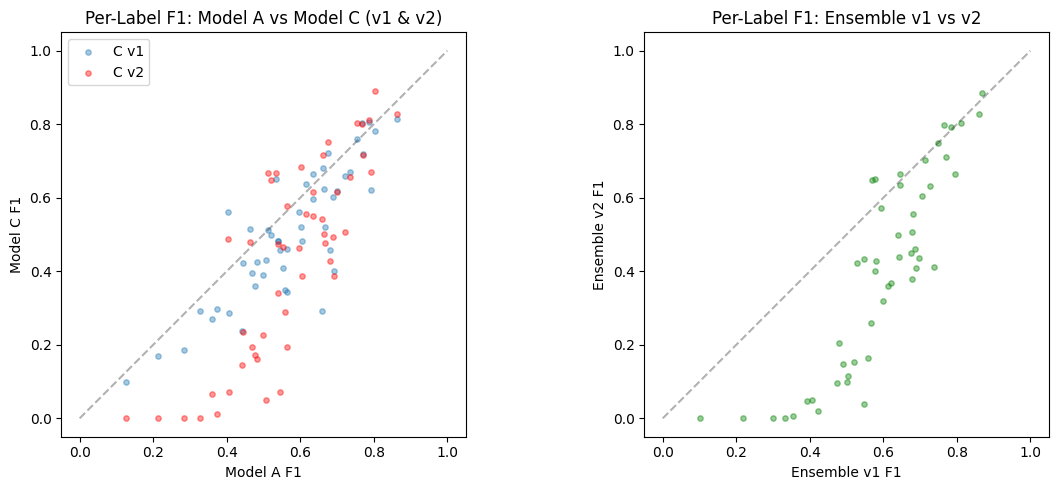

In [7]:
# Bar chart of key metrics
metrics = ['Micro-F1', 'Macro-F1', 'Micro-Prec', 'Micro-Rec', 'Micro-AUROC']
models  = comparison_df['Model'].tolist()

x = np.arange(len(metrics))
width = 0.12

fig, ax = plt.subplots(figsize=(14, 6))
for i, model_name in enumerate(models):
    row = comparison_df[comparison_df['Model'] == model_name].iloc[0]
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model_name, alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison (Test Set — Top-50 ICD-10 Codes)')
ax.set_xticks(x + width * 3)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / 'model_comparison_bars.png', dpi=150)
plt.show()

# Scatter: per-label F1 for Model A vs Model C v2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(f1_a, f1_c1, alpha=0.4, s=15, label='C v1')
axes[0].scatter(f1_a, f1_c2, alpha=0.4, s=15, c='red', label='C v2')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('Model A F1'); axes[0].set_ylabel('Model C F1')
axes[0].set_title('Per-Label F1: Model A vs Model C (v1 & v2)')
axes[0].legend(); axes[0].set_aspect('equal')

axes[1].scatter(f1_ens1, f1_ens2, alpha=0.4, s=15, c='green')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('Ensemble v1 F1'); axes[1].set_ylabel('Ensemble v2 F1')
axes[1].set_title('Per-Label F1: Ensemble v1 vs v2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / 'a_vs_c_scatter.png', dpi=120)
plt.show()

## 6. Save Ensemble Configuration

In [8]:
# Find the best ensemble
best_ens_row = comparison_df[comparison_df['Model'].str.startswith('Ensemble')].sort_values('Micro-F1', ascending=False).iloc[0]
best_ens_name = best_ens_row['Model']

# Save config for the best ensemble
ensemble_config = {
    'best_ensemble': best_ens_name,
    'ensemble_v1': {'weight_A': best_w1, 'weight_C_v1': round(1 - best_w1, 2), 'threshold': best_t1},
    'ensemble_v2': {'weight_A': best_w2, 'weight_C_v2': round(1 - best_w2, 2), 'threshold': best_t2},
    'ensemble_v3': {'weight_A': best_wa, 'weight_C_v1': best_wc1, 'weight_C_v2': best_wc2, 'threshold': best_t3},
    'test_results': rows,
}

with open(ENSEMBLE_DIR / 'ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

np.save(ENSEMBLE_DIR / 'P_ensemble_v1_test.npy', P_ens1_test)
np.save(ENSEMBLE_DIR / 'P_ensemble_v2_test.npy', P_ens2_test)
np.save(ENSEMBLE_DIR / 'P_ensemble_v3_test.npy', P_ens3_test)

print(f'Best ensemble: {best_ens_name}')
print(f'  Micro-F1: {best_ens_row["Micro-F1"]}')
print(f'  AUROC:    {best_ens_row["Micro-AUROC"]}')
print('\nAll configs and predictions saved.')

Best ensemble: Ensemble v1 (A+Cv1, w=0.65)
  Micro-F1: 0.6249
  AUROC:    0.9328

All configs and predictions saved.
